# Aos Fatos: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "aos_fatos"
PLAYER = "Aos Fatos"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,aos_fatos,aos_fatos,Aos Fatos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix, drop_generic_editorial_titles",


SpiderProfile(spider='aos_fatos', display_name='Aos Fatos', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset({'últimas notícias', 'ultimas noticias'}), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix', 'drop_generic_editorial_titles'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
14,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,4969,4936,33,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,Aos Fatos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,4936,4935,1,2015-07-17 00:00:00+00:00,2026-03-15 01:16:39+00:00,0,115


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,9510e01f69d200b2b9b14e2883116eafd33d503e38adac8227e1568f906aae24,aos_fatos,Aos Fatos,aos_fatos,https://www.aosfatos.org/noticias/?tag=tarcisio-de-freitas,https://www.aosfatos.org/noticias,Últimas notícias,2026-03-15T01:04:49+00:00,2026-03-15T01:04:49+00:00,Últimas notícias,"Leia checagens, investigações e explicadores do Aos Fatos",NaN,NaN,pt-br,BR,[],[],[],NaN,20260315T010005Z-1d265f16,2026-03-15 01:04:49+00:00,2026-03-15 01:04:49+00:00,0.0,16,16,57,www.aosfatos.org,0.0
1,474bf75daf0448d080cb721369befd6511128678022af7a987bc9189695f02ef,aos_fatos,Aos Fatos,aos_fatos,https://www.aosfatos.org/noticias/nao-e-verdade-malu-gaspar-recebeu-r-3-milhoes-daniel-vorcaro/,https://www.aosfatos.org/noticias/nao-e-verdade-malu-gaspar-recebeu-r-3-milhoes-daniel-vorcaro,Não é verdade que Malu Gaspar recebeu R$ 3 milhões de Daniel Vorcaro,2026-03-09,2026-03-15T01:04:49+00:00,Malu Gaspar recebeu R$ 3 milhões de Daniel Vorcaro em 2024,"Alegação carece de provas; além de não constar na lista de investigados pela PF, jornalista não teve seu nome divulgado nos documentos vazados pela imprensa...",Falso,1,pt-br,BR,[],"[Polícia Federal, Banco Master]",[],"Review,ClaimReview",20260315T010005Z-1d265f16,NaT,2026-03-15 01:04:49+00:00,NaN,68,58,170,www.aosfatos.org,0.0
2,c6d00fd839696d8e2744ebfe9eef91c4bc3a112979d8f097dd38a63689b97785,aos_fatos,Aos Fatos,aos_fatos,https://www.aosfatos.org/noticias/nao-e-verdade-que-moraes-recebeu-propina-para-prender-bolsonaro/,https://www.aosfatos.org/noticias/nao-e-verdade-que-moraes-recebeu-propina-para-prender-bolsonaro,Não é verdade que Moraes recebeu propina para prender Bolsonaro,2026-03-10,2026-03-15T01:04:49+00:00,PF descobre que Moraes recebeu R$ 30 milhões por mês para prender Bolsonaro,Boato foi desmentido pelo STF; Moraes não é investigado na Operação Compliance Zero,Falso,1,pt-br,BR,[],"[Jair Bolsonaro, STF, Alexandre de Moraes, Polícia Federal]",[],"Review,ClaimReview",20260315T010005Z-1d265f16,NaT,2026-03-15 01:04:49+00:00,NaN,63,75,83,www.aosfatos.org,0.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_aos_fatos:474bf75daf0448d080cb721369befd6511128678022af7a987bc9189695f02ef,474bf75daf0448d080cb721369befd6511128678022af7a987bc9189695f02ef,factcheck_scrape_aos_fatos,https://www.aosfatos.org/noticias/nao-e-verdade-malu-gaspar-recebeu-r-3-milhoes-daniel-vorcaro/,2026-03-09T00:00:00+00:00,pt-br,Não é verdade que Malu Gaspar recebeu R$ 3 milhões de Daniel Vorcaro,None,None,Malu Gaspar recebeu R$ 3 milhões de Daniel Vorcaro em 2024,"Alegação carece de provas; além de não constar na lista de investigados pela PF, jornalista não teve seu nome divulgado nos documentos vazados pela imprensa...",não é verdade que malu gaspar recebeu r$ 3 milhões de daniel vorcaro malu gaspar recebeu r$ 3 milhões de daniel vorcaro em 2024 alegação carece de provas; a...,não é verdade que malu gaspar recebeu r$ 3 milhões de daniel vorcaro malu gaspar recebeu r$ 3 milhões de daniel vorcaro em 2024 alegação carece de provas; a...,verdade malu gaspar recebeu r$ 3 milhões daniel vorcaro malu gaspar recebeu r$ 3 milhões daniel vorcaro 2024 alegação carece provas constar lista investigad...,não ser verdade que malu gaspar receber r$ 3 milhão de daniel vorcaro malu gaspar receber r$ 3 milhão de daniel vorcaro em 2024 alegação carecer de prova al...,Falso,false,Polícia Federal,"[{'text': 'malu gaspar', 'label': 'PER', 'start_char': 18, 'end_char': 29}, {'text': 'r$', 'label': 'PER', 'start_char': 38, 'end_char': 40}, {'text': 'dani...",claim_summary,298,6,aos_fatos,aos_fatos,Aos Fatos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,"Review,ClaimReview",[],"[Polícia Federal, Banco Master]",1,2026-03-09 00:00:00+00:00
1,factcheck_scrape_aos_fatos:c6d00fd839696d8e2744ebfe9eef91c4bc3a112979d8f097dd38a63689b97785,c6d00fd839696d8e2744ebfe9eef91c4bc3a112979d8f097dd38a63689b97785,factcheck_scrape_aos_fatos,https://www.aosfatos.org/noticias/nao-e-verdade-que-moraes-recebeu-propina-para-prender-bolsonaro/,2026-03-10T00:00:00+00:00,pt-br,Não é verdade que Moraes recebeu propina para prender Bolsonaro,None,None,PF descobre que Moraes recebeu R$ 30 milhões por mês para prender Bolsonaro,Boato foi desmentido pelo STF; Moraes não é investigado na Operação Compliance Zero,não é verdade que moraes recebeu propina para prender bolsonaro pf descobre que moraes recebeu r$ 30 milhões por mês para prender bolsonaro boato foi desmen...,não é verdade que moraes recebeu propina para prender bolsonaro pf descobre que moraes recebeu r$ 30 milhões por mês para prender bolsonaro boato foi desmen...,verdade moraes recebeu propina prender bolsonaro pf descobre moraes recebeu r$ 30 milhões prender bolsonaro boato desmentido stf moraes investigado operação...,não ser verdade que moraes receber propina para prender bolsonaro pf descobrir que moraes receber r$ 30 milhão por mês para prender bolsonaro boato ser desm...,Falso,false,Jair Bolsonaro,"[{'text': 'moraes', 'label': 'PER', 'start_char': 18, 'end_char': 24}, {'text': 'bolsonaro pf', 'label': 'PER', 'start_char': 54, 'end_char': 66}, {'text': ...",claim_summary,223,7,aos_fatos,aos_fatos,Aos Fatos,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,"Review,ClaimReview",[],"[Jair Bolsonaro, STF, Alexandre de Moraes, Polícia Federal]",1,2026-03-10 00:00:00+00:00
2,factcheck_scrape_aos_fatos:6c8be09a13bf0d5f5f93318e34843acc52cdcb8b349b1f9e50024cab9247c505,6c8be09a13bf0d5f5f93318e34843acc52cdcb8b349b1f9e50024cab9247c505,factcheck_scrape_aos_fatos,https://www.aosfatos.org/noticias/falso-vorcaro-confessou-te

## Text-length histograms by label

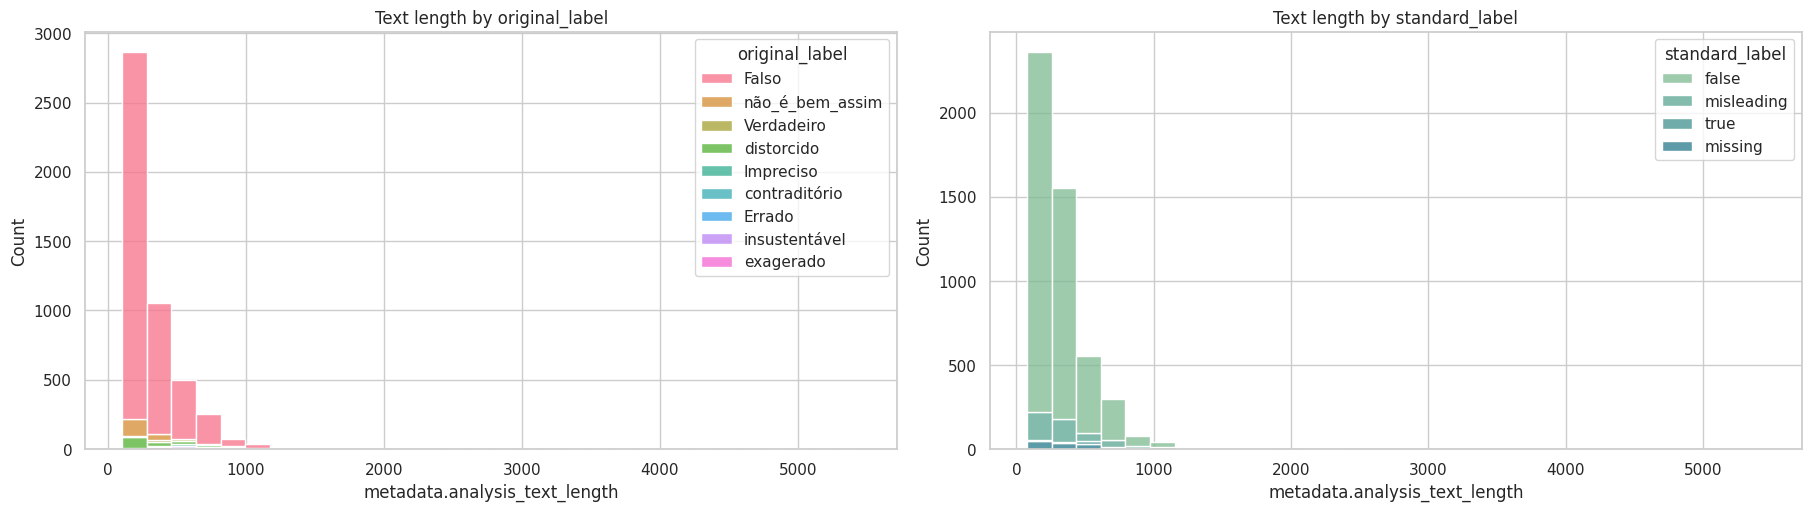

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,NaN,1119
1,Jair Bolsonaro,955
2,Luiz Inácio Lula da Silva,829
3,Covid-19,284
4,STF,190
5,saúde,182
6,Donald Trump,116
7,Eleições 2022,88
8,PT,83
9,Israel,72


,topic,count


,tag,count
0,Luiz Inácio Lula da Silva,1036
1,Jair Bolsonaro,955
2,Eleições 2022,415
3,PT,351
4,Covid-19,337
5,STF,326
6,saúde,245
7,Donald Trump,199
8,Alexandre de Moraes,179
9,Estados Unidos,158


/tmp/ipykernel_2045819/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
104,2024-04-01,57
105,2024-05-01,58
106,2024-06-01,46
107,2024-07-01,70
108,2024-08-01,85
109,2024-09-01,88
110,2024-10-01,96
111,2024-11-01,78
112,2024-12-01,59
113,2025-01-01,50


,field,missing_count
0,title,0
1,claim,0
2,summary,1
3,verdict,116
4,rating,116
5,published_at,0


,source_record_id,title,published_at


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,9510e01f69d200b2b9b14e2883116eafd33d503e38adac8227e1568f906aae24,aos_fatos,Aos Fatos,aos_fatos,https://www.aosfatos.org/noticias/?tag=tarcisio-de-freitas,https://www.aosfatos.org/noticias,Últimas notícias,2026-03-15T01:04:49+00:00,2026-03-15T01:04:49+00:00,Últimas notícias,"Leia checagens, investigações e explicadores do Aos Fatos",NaN,NaN,pt-br,BR,[],[],[],NaN,20260315T010005Z-1d265f16,2026-03-15 01:04:49+00:00,2026-03-15 01:04:49+00:00,0.0,16,16,57,www.aosfatos.org,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,474bf75daf0448d080cb721369befd6511128678022af7a987bc9189695f02ef,aos_fatos,Aos Fatos,aos_fatos,https://www.aosfatos.org/noticias/nao-e-verdade-malu-gaspar-recebeu-r-3-milhoes-daniel-vorcaro/,https://www.aosfatos.org/noticias/nao-e-verdade-malu-gaspar-recebeu-r-3-milhoes-daniel-vorcaro,Não é verdade que Malu Gaspar recebeu R$ 3 milhões de Daniel Vorcaro,2026-03-09,2026-03-15T01:04:49+00:00,Malu Gaspar recebeu R$ 3 milhões de Daniel Vorcaro em 2024,"Alegação carece de provas; além de não constar na lista de investigados pela PF, jornalista não teve seu nome divulgado nos documentos vazados pela imprensa...",Falso,1,pt-br,BR,[],"[Polícia Federal, Banco Master]",[],"Review,ClaimReview",20260315T010005Z-1d265f16,NaT,2026-03-15 01:04:49+00:00,NaN,68,58,170,www.aosfatos.org,0.0,Não é verdade que Malu Gaspar recebeu R$ 3 milhões de Daniel Vorcaro,Malu Gaspar recebeu R$ 3 milhões de Daniel Vorcaro em 2024,"Alegação carece de provas; além de não constar na lista de investigados pela PF, jornalista não teve seu nome divulgado nos documentos vazados pela imprensa...",não é verdade que malu gaspar recebeu r$ 3 milhões de daniel vorcaro malu gaspar recebeu r$ 3 milhões de daniel vorcaro em 2024 alegação carece de provas; a...,Falso,false,2026-03-09T00:00:00+00:00
2,c6d00fd839696d8e2744ebfe9eef91c4bc3a112979d8f097dd38a63689b97785,aos_fatos,Aos Fatos,aos_fatos,https://www.aosfatos.org/noticias/nao-e-verdade-que-moraes-recebeu-propina-para-prender-bolsonaro/,https://www.aosfatos.org/noticias/nao-e-verdade-que-moraes-recebeu-propina-para-prender-bolsonaro,Não é verdade que Moraes recebeu propina para prender Bolsonaro,2026-03-10,2026-03-15T01:04:49+00:00,PF descobre que Moraes recebeu R$ 30 milhões por mês para prender Bolsonaro,Boato foi desmentido pelo STF; Moraes não é investigado na Operação Compliance Zero,Falso,1,pt-br,BR,[],"[Jair Bolsonaro, STF, Alexandre de Moraes, Polícia Federal]",[],"Review,ClaimReview",20260315T010005Z-1d265f16,NaT,2026-03-15 01:04:49+00:00,NaN,63,75,83,www.aosfatos.org,0.0,Não é verdade que Moraes recebeu propina para prender Bolsonaro,PF descobre que Moraes recebeu R$ 30 milhões por mês para prender Bolsonaro,Boato foi desmentido pelo STF; Moraes não é investigado na Operação Compliance Zero,não é verdade que moraes recebeu propina para prender bolsonaro pf descobre que moraes recebeu r$ 30 milhões por mês para prender bolsonaro boato foi desmen...,Falso,false,2026-03-10T00:00:00+00:00
3,6c8be09a13bf0d5f5f93318e34843acc52cdcb8b349b1f9e50024cab9247c505,aos_fatos,Aos Fatos,aos_fatos,https://www.aosfatos.org/noticias/falso-vorcaro-confessou-ter-feito-pagamentos-lula-ministros-stf/,https://www.aosfatos.org/noticias/falso-vorcaro-confessou-ter-feito-pagamentos-lula-ministros-stf,É falso que Vorcaro confessou ter feito pagamentos a Lula e a ministros do STF,2026-03-10,2026-03-15T01:04:49+00:00,"Em vídeo, jornalista diz que Vorcaro surtou na cadeia e confessou ter feito pagamentos a Lula e ao STF",Trata-se de um telejornal gerado por IA que compartilha histórias fictícias,Falso,1,pt-br,BR,[],"[Luiz Inácio Lula da Silva, ST

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,o,34751
1,de,27130
2,em,14392
3,ser,9737
4,que,8835
5,não,5451
6,e,5088
7,a,4553
8,por,3770
9,um,2816


,text,label,start_char,end_char
0,malu gaspar,PER,18,29
0,r$,PER,38,40
0,daniel vorcaro malu gaspar,PER,54,80
0,r$,PER,89,91
0,daniel vorcaro,PER,105,119
0,pf,ORG,205,207
1,moraes,PER,18,24
1,bolsonaro pf,PER,54,66
1,moraes,PER,80,86
1,r$,PER,95,97


,label,count
0,LOC,7935
1,PER,7712
2,ORG,2501
3,MISC,1036


,source_record_id,text_without_stopwords,lemmatized_text
0,474bf75daf0448d080cb721369befd6511128678022af7a987bc9189695f02ef,verdade malu gaspar recebeu r$ 3 milhões daniel vorcaro malu gaspar recebeu r$ 3 milhões daniel vorcaro 2024 alegação carece provas constar lista investigad...,não ser verdade que malu gaspar receber r$ 3 milhão de daniel vorcaro malu gaspar receber r$ 3 milhão de daniel vorcaro em 2024 alegação carecer de prova al...
1,c6d00fd839696d8e2744ebfe9eef91c4bc3a112979d8f097dd38a63689b97785,verdade moraes recebeu propina prender bolsonaro pf descobre moraes recebeu r$ 30 milhões prender bolsonaro boato desmentido stf moraes investigado operação...,não ser verdade que moraes receber propina para prender bolsonaro pf descobrir que moraes receber r$ 30 milhão por mês para prender bolsonaro boato ser desm...
2,6c8be09a13bf0d5f5f93318e34843acc52cdcb8b349b1f9e50024cab9247c505,falso vorcaro confessou feito pagamentos lula ministros stf vídeo jornalista vorcaro surtou cadeia confessou feito pagamentos lula stf trata-se telejornal g...,ser falso que vorcaro confessar ter fazer pagamento a lula e o ministro de o stf em vídeo jornalista dizer que vorcaro surtar em o cadeia e confessar ter fa...
3,12794a5be37fa1edf8e6b48b9e08b1566fdc7e96fe6dcd325da3206e5957f572,vídeo alexandre moraes ameaças gerado ia vídeo alexandre moraes ameaças adversários deles guardado trata-se vídeo manipulado ia,vídeo em que alexandre de moraes fazer ameaça ser gerar por ia em vídeo alexandre de moraes fazer ameaça a adversário e dizer o que ser de eles estar guarda...
4,59f255445cfd8aac71da74ca9cba58372b309533c42ae2138bec0e268392119b,posts usam ia alegar eua teriam bombardeado caças pintados chão iranianos imagens mostram eua bombardearam pinturas caças iranianos registros circulam redes...,post usar ir para alegar que eua ter bombardear caça pintar em o chão por iraniano imagem mostrar que eua bombardear pintura de caça iraniano registro que c...
5,74911572874fe83296b615ea81cf3318cf32e791805aa75a4f063ff58692ed5c,vídeos mostram policiais israelenses destruindo câmeras impedir registros ataques irã vídeo mostra policiais israelenses destruindo câmeras evitar ataques i...,vídeo não mostrar policial israelense destruir câmera para impedir registro de ataque de o irã vídeo mostrar policial israelense destruir câmera para evitar...
6,1cc78fc731b3bb6d2e0a7f1536ae2fd89f8159a697320349cb48866fec924cd5,vídeo mostra ataques irã israel simulação vídeo mostra ataque irã israel trata-se simulação gerada computação gráfica,vídeo que mostrar ataque de o irã a israel ser simulação vídeo mostrar ataque de o irã contra israel tratar se de um simulação gerar por computação gráfico
7,0257ee0c9614e405c555dac9821a1880a984aab8e913d61063773b76140af79f,falso brasil sofrer desabastecimento combustível quinta-feira haverá combustíveis postos brasileiros quinta-feira 12 anp petrobras negam brasil sofrer desab...,ser falso que brasil poder sofrer desabastecimento de combustível a partir de este quinta-feira não haver mais combustível em o posto brasileiro a partir de...
8,1c8984a1274fb5dddb59f15afbfde7534c7413d2c1d2a963768c6a774eff412c,verdade foto mostra míssil iraniano mensagem vítimas epstein míssil iraniano mostra inscrição persa alusão vítimas epstein foto editada ferramenta ia gemini...,não ser verdade que fotor mostrar míssil iraniano com mensagem sobre vítima de epstein míssil iraniano mostrar inscrição em persa que fazer alusão a o vítim...
9,869d2766bd70881e142b1e93e9240a2e6f93485a57389f498c0c2c338f884c5d,falso vorcaro agradeceu malu gaspar durante evento york vorcaro agradeceu malu gaspar evento 2024 gaspar evento vorcaro menção malu filgueiras editora pipel...,ser falso que vorcaro agradecer o malu gaspar durante evento em nova york vorcaro agradecer malu gaspar em evento de o valor em 2024 gaspar não estar em o e...


## Export processed JSONL

In [9]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260315T231838Z-aos_fatos,4935,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231838Z-aos_fatos/spiders/aos_fatos.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231838Z-aos_fatos/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231838Z-aos_fatos/manifest.json
